<a href="https://colab.research.google.com/github/2310256-sketch/hye/blob/main/bareun_lecture_ipyng.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 바른 형태소 분석기 실무 활용
## — Python 기반 한국어 언어 분석 입문 —

---

### 📌 강의 개요

이 노트북은 **바른(Bareun) 형태소 분석기**를 활용해 한국어 텍스트를 분석하는 방법을 단계별로 안내합니다.  
언어 연구, 임상 자료 분석, 텍스트 마이닝 등 실무에 바로 적용할 수 있도록 구성되었습니다.

---

### 🎯 학습 목표

이 강의를 마치면 다음을 할 수 있습니다:

1. 바른 형태소 분석기를 설치하고 API 키를 설정할 수 있다
2. 한국어 텍스트를 형태소 단위로 분석하고 품사를 확인할 수 있다
3. 원하는 품사(명사, 동사 등)만 선별하여 추출할 수 있다
4. 여러 텍스트를 일괄 처리하고 결과를 정리할 수 있다
5. 빈도 분석, 언어적 지표, 시각화를 통해 텍스트를 비교·분석할 수 있다
6. 결과를 CSV/Excel 파일로 저장하고 내보낼 수 있다

---

### 📋 강의 구성

| 단계 | 내용 | 난이도 |
|:---:|------|:---:|
| 1 | 설치 및 환경 설정 | ⭐ |
| 2 | 형태소 분석이란? — 이론 정리 | ⭐ |
| 3 | 기본 형태소 분석 | ⭐ |
| 4 | 품사별 필터링 | ⭐⭐ |
| 5 | 불용어 처리 | ⭐⭐ |
| 6 | 빈도 분석과 DataFrame | ⭐⭐ |
| 7 | 파일 일괄 처리 | ⭐⭐⭐ |
| 8 | 시각화 | ⭐⭐ |
| 9 | 언어적 지표 계산 | ⭐⭐⭐ |
| 10 | 결과 내보내기 | ⭐ |
| 11 | 그룹 간 비교 분석 | ⭐⭐⭐ |
| 12 | 전체 파이프라인 | ⭐⭐⭐ |

---

> 💡 **이 노트북 사용법**  
> - 각 셀은 **위에서 아래 순서대로** 실행하세요.  
> - 코드 셀 왼쪽의 ▶ 버튼을 클릭하거나 `Shift + Enter`를 누르면 실행됩니다.  
> - 처음 실행 시 패키지 설치에 1~2분 정도 소요될 수 있습니다.

---
## 1단계. 설치 및 환경 설정

### 📖 배경 지식: 바른(Bareun) 형태소 분석기란?

**바른**은 국립국어원이 개발을 지원한 한국어 형태소 분석기입니다.  
클라우드 API 방식으로 제공되며, 간단한 Python 패키지 설치만으로 사용할 수 있습니다.

| 특징 | 내용 |
|------|------|
| 분석 방식 | 클라우드 API (인터넷 연결 필요) |
| 무료 사용량 | 월 50만 어절 (무료 계정 기준) |
| 태그셋 | 세종 품사 태그셋 기반 |
| API 키 발급 | https://bareun.ai 회원가입 후 발급 |

### 🛠 설치 구성요소

이 셀에서는 다음 패키지들을 설치합니다:

- **`bareunpy`** — 바른 형태소 분석기 Python 클라이언트
- **`wordcloud`** — 워드클라우드 시각화
- **`matplotlib`** — 그래프 그리기
- **`pandas`** — 데이터를 표(DataFrame) 형태로 다루기
- **`openpyxl`** — Excel 파일 저장
- **`fonts-nanum`** — 한글 폰트 (그래프에서 한글이 깨지지 않도록)

In [ ]:
!pip install streamlit
import streamlit as st
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from wordcloud import WordCloud
import pandas as pd
import os

# ────────────────────────────────────────────────────────────
# 1. 스트림릿용 한글 폰트 설정 로직
# ────────────────────────────────────────────────────────────
@st.cache_resource
def set_korean_font():
    # 1. 리포지토리에 NanumGothic.ttf 파일을 같이 올렸을 경우를 가정
    local_font_path = 'NanumGothic.ttf'

    if os.path.exists(local_font_path):
        # 폰트 매니저에 등록
        fe = fm.FontEntry(fname=local_font_path, name='NanumGothic')
        fm.fontManager.ttflist.insert(0, fe)
        plt.rcParams['font.family'] = fe.name
        return local_font_path
    else:
        # 2. 리눅스 서버(Streamlit Cloud) 기본 경로 확인
        linux_font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
        if os.path.exists(linux_font_path):
            plt.rc('font', family='NanumGothic')
            return linux_font_path
    return None

font_path = set_korean_font()
plt.rcParams['axes.unicode_minus'] = False

# ────────────────────────────────────────────────────────────
# 2. 스트림릿 화면 구성
# ────────────────────────────────────────────────────────────
st.title("📊 한글 텍스트 시각화 도구")
st.markdown("텍스트를 입력하면 분석 결과와 워드클라우드를 생성합니다.")

# 입력 섹션
with st.sidebar:
    st.header("설정")
    user_input = st.text_area("분석할 텍스트를 입력하세요", placeholder="안녕하세요. 반갑습니다.", height=200)
    process_btn = st.button("분석 실행")

# 출력 섹션
if process_btn:
    if not user_input.strip():
        st.warning("텍스트를 먼저 입력해주세요!")
    else:
        # 간단 빈도 분석
        words = user_input.split()
        word_counts = pd.Series(words).value_counts().to_dict()

        # 레이아웃 나누기
        col1, col2 = st.columns(2)

        with col1:
            st.subheader("📝 분석 요약")
            st.write(f"**총 단어 수:** {len(words)}개")
            st.write(f"**고유 단어 수:** {len(word_counts)}개")
            st.dataframe(pd.Series(word_counts).head(10), column_config={"value": "빈도"})

        with col2:
            st.subheader("☁️ 워드클라우드")
            # 워드클라우드 생성
            wc = WordCloud(
                font_path=font_path,  # 한글 폰트 경로 지정 필수
                background_color='white',
                width=800,
                height=600
            ).generate_from_frequencies(word_counts)

            fig, ax = plt.subplots(figsize=(10, 8))
            ax.imshow(wc, interpolation='bilinear')
            ax.axis('off')
            st.pyplot(fig)

        st.success("✅ 시각화가 완료되었습니다!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 73.0 MB/s eta 0:00:00


2026-04-30 00:45:44.004 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-30 00:45:44.006 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-30 00:45:44.198 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-30 00:45:44.199 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-30 00:45:44.200 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-30 00:45:44.201 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-30 00:45:44.204 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

### 🔑 API 키 설정

바른 분석기를 사용하려면 **API 키**가 필요합니다.  
API 키는 https://bareun.ai 에서 무료로 발급받을 수 있습니다.

#### 보안 권장 방법: Colab Secrets 사용

API 키를 코드에 직접 입력하면 노트북 공유 시 키가 노출될 수 있습니다.  
Colab Secrets를 사용하면 키를 안전하게 보관할 수 있습니다.

**등록 방법:**  
① 화면 왼쪽 자물쇠(🔒) 아이콘 클릭  
② `+ 새 보안 비밀 추가` 클릭  
③ 이름: `BAREUN_API_KEY`, 값: 발급받은 API 키 입력  
④ 노트북 액세스 토글 ON  

> ⚠️ Secrets가 없는 환경에서는 실행 시 직접 입력 창이 나타납니다.

In [ ]:
# ════════════════════════════════════════════════════════════
#  API 키 설정 및 분석기 초기화
# ════════════════════════════════════════════════════════════

# 방법 1: Colab Secrets에서 자동으로 불러오기 (권장)
# 방법 2: 직접 입력창으로 받기 (Secrets가 없을 때 자동 전환)

import os
from bareunpy import Tagger

try:
    from google.colab import userdata
    BAREUN_API_KEY = userdata.get('BAREUN_API_KEY')
    print('✅ Colab Secrets에서 API 키를 불러왔습니다.')
except Exception:
    # Secrets 등록이 없거나 실패한 경우, 직접 입력을 요청합니다.
    BAREUN_API_KEY = input('🔑 바른 API 키를 입력하세요: ').strip()

# bareunpy 라이브러리가 환경 변수에서 API 키를 읽어올 수 있도록 설정
os.environ['BAREUN_API_KEY'] = BAREUN_API_KEY

# ────────────────────────────────────────────────────────────
#  Tagger 객체 생성
# ────────────────────────────────────────────────────────────
# Tagger는 형태소 분석의 핵심 객체입니다.
# domain='GENERAL' : 일반 도메인 (의료, 법률 등 특수 도메인도 지원)

tagger = Tagger(apikey=BAREUN_API_KEY)

print('✅ 바른 형태소 분석기 초기화 완료')
print('   이제 tagger 객체를 통해 형태소 분석을 수행할 수 있습니다.')

✅ Colab Secrets에서 API 키를 불러왔습니다.
✅ 바른 형태소 분석기 초기화 완료
   이제 tagger 객체를 통해 형태소 분석을 수행할 수 있습니다.


---
## 2단계. 형태소 분석 이론 정리

### 📖 형태소(Morpheme)란?

> **형태소**란 의미를 가진 언어의 최소 단위입니다.

예를 들어 **"할머니께서는"** 을 분석하면:

| 형태소 | 품사 | 설명 |
|--------|------|------|
| 할머니 | NNG | 일반 명사 |
| 께서 | JKS | 주격 조사 (높임) |
| 는 | JX | 보조사 |

---

### 📖 품사 태그 핵심 목록

바른 형태소 분석기는 **세종 품사 태그셋**을 기반으로 합니다.  
아래는 연구에서 자주 사용하는 핵심 태그들입니다.

다음 셀을 실행하면 전체 태그 참조표를 확인할 수 있습니다.

In [ ]:
# ════════════════════════════════════════════════════════════
#  품사 태그 참조표 출력
# ════════════════════════════════════════════════════════════
#
# 이 딕셔너리(POS_TABLE)는 이후 모든 셀에서 태그 설명을 조회하는
# 기준 데이터로 활용됩니다. 반드시 이 셀을 먼저 실행하세요.
#
# 구조: { '분류명': { '태그코드': '설명', ... }, ... }

import pandas as pd

POS_TABLE = {
    '체언(명사류)': {
        'NNG': '일반 명사',   'NNP': '고유 명사',  'NNB': '의존 명사',
        'NP':  '대명사',      'NR':  '수사'
    },
    '용언(서술어류)': {
        'VV':  '동사',        'VA':  '형용사',      'VX':  '보조 용언',
        'VCP': '긍정 지정사', 'VCN': '부정 지정사'
    },
    '수식언': {
        'MM':  '관형사',      'MAG': '일반 부사',   'MAJ': '접속 부사'
    },
    '독립언': {
        'IC':  '감탄사'
    },
    '관계언(조사류)': {
        'JKS': '주격 조사',   'JKC': '보격 조사',  'JKG': '관형격 조사',
        'JKO': '목적격 조사', 'JKB': '부사격 조사','JKV': '호격 조사',
        'JKQ': '인용격 조사', 'JX':  '보조사',     'JC':  '접속 조사'
    },
    '어미': {
        'EP':  '선어말 어미', 'EF':  '종결 어미',  'EC':  '연결 어미',
        'ETN': '명사형 어미', 'ETM': '관형형 어미'
    },
    '접사': {
        'XPN': '체언 접두사',     'XSN': '명사 파생 접미사',
        'XSV': '동사 파생 접미사','XSA': '형용사 파생 접미사'
    },
    '기호·외국어·숫자': {
        'SF':  '마침표·느낌표·물음표', 'SP': '쉼표·콜론',
        'SS':  '따옴표·괄호',         'SW': '기타 기호',
        'SL':  '외국어',              'SH': '한자',
        'SN':  '숫자'
    },
    '기타': {
        'XR':  '어근',  'UN': '분석 불능'
    }
}

# 딕셔너리를 DataFrame으로 변환하여 보기 좋게 출력
rows = []
for cat, tags in POS_TABLE.items():
    for tag, desc in tags.items():
        rows.append({'분류': cat, '태그': tag, '설명': desc})

df_pos = pd.DataFrame(rows)

print('📌 바른 형태소 분석기 품사 태그 전체 목록')
print('   (이 표는 이후 분석 결과의 품사 설명에 자동으로 활용됩니다)\n')
display(df_pos.style
        .set_properties(**{'text-align': 'left'})
        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}]))

📌 바른 형태소 분석기 품사 태그 전체 목록
   (이 표는 이후 분석 결과의 품사 설명에 자동으로 활용됩니다)



,분류,태그,설명
0,체언(명사류),NNG,일반 명사
1,체언(명사류),NNP,고유 명사
2,체언(명사류),NNB,의존 명사
3,체언(명사류),NP,대명사
4,체언(명사류),NR,수사
5,용언(서술어류),VV,동사
6,용언(서술어류),VA,형용사
7,용언(서술어류),VX,보조 용언
8,용언(서술어류),VCP,긍정 지정사
9,용언(서술어류),VCN,부정 지정사


---
## 3단계. 기본 형태소 분석

### 📖 핵심 개념: `tagger.tag()` 메서드

바른 분석기의 핵심 메서드는 `tagger.tag(텍스트)` 입니다.  
이 메서드는 분석 결과 객체를 반환하며, 여기서 다양한 형태로 결과를 추출할 수 있습니다.

```python
tagged = tagger.tag('안녕하세요.')

tagged.morphs()   # → ['안녕', '하', '세요', '.']
tagged.pos()      # → [('안녕', 'NNG'), ('하', 'XSV'), ('세요', 'EF'), ('.', 'SF')]
tagged.nouns()    # → ['안녕']
```

### 💡 `analyze_text()` 함수 설명

아래 함수는 `tagger.tag()`를 감싸서(wrapper),  
결과를 보기 좋은 DataFrame 형태로 출력하는 **편의 함수**입니다.  

- `verbose=True` : 결과를 표로 출력 (확인용)
- `verbose=False` : 표 출력 없이 데이터만 반환 (대량 처리용)

In [ ]:
# ════════════════════════════════════════════════════════════
#  기본 형태소 분석 함수 정의
# ════════════════════════════════════════════════════════════

def analyze_text(text: str, verbose: bool = True) -> list:
    """
    텍스트를 형태소 분석하여 (형태소, 품사) 튜플 리스트를 반환합니다.

    매개변수
    --------
    text    : 분석할 한국어 텍스트 (문자열)
    verbose : True이면 결과 표를 출력, False이면 조용히 데이터만 반환

    반환값
    ------
    list of tuple : [('형태소', '품사태그'), ...]
    예: [('할머니', 'NNG'), ('께서', 'JKS'), ('는', 'JX')]
    """
    # API를 호출하여 형태소 분석 수행
    tagged = tagger.tag(text)

    # .pos()는 (형태소, 품사태그) 쌍의 리스트를 반환합니다.
    pos = tagged.pos()

    if verbose:
        # DataFrame으로 변환하여 보기 좋게 출력
        df = pd.DataFrame(pos, columns=['형태소', '품사'])

        # POS_TABLE을 이용하여 품사 설명 컬럼 추가
        # {k: v for d in ... for k, v in d.items()} 는
        # 중첩 딕셔너리를 하나의 평면 딕셔너리로 펼치는 구문입니다.
        flat_pos = {k: v for d in POS_TABLE.values() for k, v in d.items()}
        df['품사 설명'] = df['품사'].map(flat_pos).fillna('—')

        print(f'\n📝 입력 텍스트: {text}')
        print(f'🔢 분석 결과: 형태소 {len(pos)}개')
        print()
        display(df)

    return pos


# ════════════════════════════════════════════════════════════
#  실습: 아래 텍스트를 직접 바꿔보세요!
# ════════════════════════════════════════════════════════════
sample_text = '코스피가 2일 이란 전쟁 종식에 대한 기대감에 장 초반 상승했다가 도널드 트럼프 미국 대통령의 대국민 연설 이후 다시 하락했다.'

result = analyze_text(sample_text)


📝 입력 텍스트: 코스피가 2일 이란 전쟁 종식에 대한 기대감에 장 초반 상승했다가 도널드 트럼프 미국 대통령의 대국민 연설 이후 다시 하락했다.
🔢 분석 결과: 형태소 30개



,형태소,품사,품사 설명
0,코스피,NNP,고유 명사
1,가,JKS,주격 조사
2,2,SN,숫자
3,일,NNB,의존 명사
4,이란,NNP,고유 명사
5,전쟁,NNG,일반 명사
6,종식,NNG,일반 명사
7,에,JKB,부사격 조사
8,대하,VV,동사
9,ㄴ,ETM,관형형 어미


### 🔍 결과 해석 연습

위 분석 결과에서 확인해 보세요:

1. **'할머니'** 는 어떤 품사로 분류되었나요?
2. **'사셨는데'** 는 몇 개의 형태소로 나뉘었나요?
3. **'맛있었다고'** 에서 **어간**과 **어미**를 구분해 보세요.

> 💡 동사/형용사는 어간과 어미가 분리됩니다.  
> 예: `맛있 + 었 + 다고` → `VA + EP + EC`

---

### ✏️ 실습 문제
아래 셀에서 `sample_text`를 여러분이 원하는 문장으로 바꾸어 실행해 보세요.

In [ ]:
# ════════════════════════════════════════════════════════════
#  ✏️ 실습: 원하는 문장을 입력해 보세요
# ════════════════════════════════════════════════════════════

# 아래 텍스트를 원하는 문장으로 바꿔 실행해 보세요.
my_text = '노인성 치매 환자들은 대화 중 단어 인출에 어려움을 보인다.'

result_practice = analyze_text(my_text)


📝 입력 텍스트: 노인성 치매 환자들은 대화 중 단어 인출에 어려움을 보인다.
🔢 분석 결과: 형태소 16개



,형태소,품사,품사 설명
0,노인,NNG,일반 명사
1,성,XSN,명사 파생 접미사
2,치매,NNG,일반 명사
3,환자,NNG,일반 명사
4,들,XSN,명사 파생 접미사
5,은,JX,보조사
6,대화,NNG,일반 명사
7,중,NNB,의존 명사
8,단어,NNG,일반 명사
9,인출,NNG,일반 명사


---
## 4단계. 품사별 필터링

### 📖 왜 품사 필터링이 필요한가?

형태소 분석 결과에는 **조사, 어미, 기호** 등 분석 목적과 무관한 요소가 많이 포함됩니다.  
연구 목적에 따라 필요한 품사만 선별하면 분석의 정확도와 효율이 높아집니다.

| 연구 목적 | 권장 품사 추출 |
|-----------|---------------|
| 주제어/키워드 분석 | 명사 (NNG, NNP) |
| 서술 행위 분석 | 동사 (VV) |
| 감정·평가 분석 | 형용사 (VA) |
| 어휘 다양도(TTR) | 내용어 전체 (NNG+NNP+VV+VA) |
| 담화 분석 | 내용어 + 부사 (open class) |

### 💡 프리셋(Preset) 시스템

`POS_PRESETS` 딕셔너리에 자주 쓰는 품사 조합을 미리 저장해 두었습니다.  
`preset='nouns'`처럼 이름으로 불러올 수 있어 편리합니다.  
필요하면 직접 새 프리셋을 추가하세요.

In [ ]:
# ════════════════════════════════════════════════════════════
#  품사별 필터링 함수 정의
# ════════════════════════════════════════════════════════════

# ── 품사 프리셋 정의 ──────────────────────────────────────────
# 자주 사용하는 품사 조합을 이름으로 미리 정의해 둡니다.
# 필요에 따라 항목을 추가하거나 수정하세요.

POS_PRESETS = {
    # 명사류 전체 (일반/고유/의존 명사, 대명사, 수사)
    'nouns':      ['NNG', 'NNP', 'NNB', 'NP', 'NR'],

    # 동사만 (보조용언 제외)
    'verbs':      ['VV'],

    # 보조용언 포함 동사 전체
    'verbs_all':  ['VV', 'VX'],

    # 형용사만
    'adjectives': ['VA'],

    # 내용어: 명사 + 동사 + 형용사
    'content':    ['NNG', 'NNP', 'VV', 'VA'],

    # 개방 품사 (어휘 다양도 계산 시 권장)
    'open_class': ['NNG', 'NNP', 'VV', 'VA', 'MAG', 'MM'],

    # 전체 (필터 없음)
    'all_pos':    None
}


def filter_by_pos(pos_list: list, pos_filter=None,
                  preset: str = None, min_length: int = 1) -> list:
    """
    (형태소, 품사) 리스트에서 원하는 품사만 추출합니다.

    매개변수
    --------
    pos_list   : analyze_text()의 반환값
    pos_filter : 추출할 품사 태그 리스트 (예: ['NNG', 'NNP'])
    preset     : 미리 정의된 프리셋 이름 (pos_filter보다 우선)
    min_length : 형태소 최소 글자 수 (1음절 단어 제거에 활용)

    반환값
    ------
    list of tuple : 필터링된 (형태소, 품사) 리스트
    """
    # 프리셋이 지정된 경우, 프리셋의 태그 목록을 사용합니다.
    if preset:
        pos_filter = POS_PRESETS.get(preset)

    filtered = [
        (morph, tag)
        for morph, tag in pos_list
        # pos_filter가 None이면 전체 허용, 아니면 지정 태그만
        if (pos_filter is None or tag in pos_filter)
        # min_length보다 짧은 형태소 제거
        and len(morph) >= min_length
    ]
    return filtered


# ════════════════════════════════════════════════════════════
#  실습: 여러 프리셋 비교
# ════════════════════════════════════════════════════════════

# 분석에 사용할 예시 단락
sample_para = """
노인성 치매 환자들은 대화 중 단어 인출에 어려움을 보이며, 주제 유지 능력이 저하되는 경향이 있다.
경도 인지장애 단계에서는 어휘 다양도가 감소하고 반복적 발화가 증가하는 양상을 보인다.
정상 노인과 치매 노인의 담화 특성을 비교하는 연구가 활발히 진행되고 있다.
"""

# verbose=False: 화면 출력 없이 데이터만 받아옵니다 (대량 처리 시 활용)
pos_result = analyze_text(sample_para, verbose=False)

print('=' * 50)
print('프리셋별 추출 결과 비교')
print('=' * 50)

# 1. 명사만 추출 (2글자 이상)
nouns = filter_by_pos(pos_result, preset='nouns', min_length=2)
print('\n[명사] preset="nouns", min_length=2')
print([m for m, t in nouns])

# 2. 동사만 추출
verbs = filter_by_pos(pos_result, preset='verbs')
print('\n[동사] preset="verbs"')
print([m for m, t in verbs])

# 3. 내용어 (명사+동사+형용사, 2글자 이상)
content = filter_by_pos(pos_result, preset='content', min_length=2)
print('\n[내용어] preset="content", min_length=2')
print([m for m, t in content])

# 4. 직접 지정 방식 — 예: 일반명사 + 고유명사만
specific = filter_by_pos(pos_result, pos_filter=['NNG', 'NNP'], min_length=2)
print('\n[직접 지정] pos_filter=["NNG", "NNP"]')
print([m for m, t in specific])

프리셋별 추출 결과 비교

[명사] preset="nouns", min_length=2
['노인', '치매', '환자', '대화', '단어', '인출', '어려움', '주제', '유지', '능력', '경향', '경도', '인지', '장애', '단계', '어휘', '다양도', '반복', '발화', '양상', '정상', '노인', '치매', '노인', '담화', '특성', '연구']

[동사] preset="verbs"
['보이', '저하되', '감소하', '증가하', '보이', '비교하', '진행되']

[내용어] preset="content", min_length=2
['노인', '치매', '환자', '대화', '단어', '인출', '어려움', '보이', '주제', '유지', '능력', '저하되', '경향', '경도', '인지', '장애', '단계', '어휘', '다양도', '감소하', '반복', '발화', '증가하', '양상', '보이', '정상', '노인', '치매', '노인', '담화', '특성', '비교하', '연구', '진행되']

[직접 지정] pos_filter=["NNG", "NNP"]
['노인', '치매', '환자', '대화', '단어', '인출', '어려움', '주제', '유지', '능력', '경향', '경도', '인지', '장애', '단계', '어휘', '다양도', '반복', '발화', '양상', '정상', '노인', '치매', '노인', '담화', '특성', '연구']


---
## 5단계. 불용어(Stopword) 처리

### 📖 불용어(Stopword)란?

> 분석 목적과 무관하게 자주 등장하는 **의미 없는 단어**들을 말합니다.

품사 필터링으로 명사만 추출해도 **'것', '수', '때', '이'** 같은 의존 명사나  
의미가 약한 단어들이 남아 빈도를 왜곡할 수 있습니다.

#### 불용어 처리가 필요한 이유

```
필터링 전: ['것', '수', '노인', '때', '치매', '연구', '것', '환자']
필터링 후: ['노인', '치매', '환자', '연구']
```

**→ 실제 핵심 단어의 빈도와 순위가 더 명확하게 드러납니다.**

### 💡 불용어 목록 관리 방법

- `DEFAULT_STOPWORDS`: 일반적으로 제거할 기본 불용어 세트
- `custom_stopwords`: 연구 도메인에 맞게 추가 불용어를 지정
- 연구 분야나 코퍼스 특성에 따라 목록을 조정하는 것을 권장합니다.

In [ ]:
# ════════════════════════════════════════════════════════════
#  불용어 처리 함수 정의
# ════════════════════════════════════════════════════════════

# 기본 불용어 사전 (set 자료형 → 빠른 검색을 위해 집합으로 저장)
# 연구 목적에 따라 수정하세요.

DEFAULT_STOPWORDS = {
    # 의존 명사 / 형식 명사
    '것', '수', '때', '등', '중', '후', '전', '위',
    # 관형어처럼 쓰이는 단음절 형태소
    '이', '그', '저', '더', '또', '만', '도',
    # 대명사
    '이것', '그것', '저것', '여기', '거기', '저기',
    # 빈도는 높지만 내용이 없는 동사/형용사
    '있다', '없다', '되다', '하다', '이다',
    # 시간·단위 표현
    '년', '월', '일', '시', '분',
    # 연결·접속 부사
    '및', '또한', '즉', '그리고', '하지만', '그러나', '그래서',
    # 기타 고빈도 기능어
    '위해', '통해', '대해', '관해', '따라', '만약'
}


def remove_stopwords(morph_list: list,
                     stopwords: set = None,
                     custom_stopwords: list = None) -> list:
    """
    불용어를 제거하고 정제된 형태소 리스트를 반환합니다.

    매개변수
    --------
    morph_list       : (형태소, 품사) 리스트
    stopwords        : 기본 불용어 세트 (None이면 DEFAULT_STOPWORDS 사용)
    custom_stopwords : 추가로 제거할 단어 리스트

    반환값
    ------
    불용어가 제거된 (형태소, 품사) 리스트
    """
    # 기본 불용어 + 사용자 지정 불용어를 합집합(|)으로 합칩니다.
    sw = stopwords if stopwords is not None else DEFAULT_STOPWORDS.copy()
    if custom_stopwords:
        sw = sw | set(custom_stopwords)   # set.union() 연산

    # 형태소가 불용어 집합에 없는 것만 남깁니다.
    return [(m, t) for m, t in morph_list if m not in sw]


# ════════════════════════════════════════════════════════════
#  실습: 불용어 처리 전후 비교
# ════════════════════════════════════════════════════════════

# 1단계: 명사 필터링
nouns_raw = filter_by_pos(pos_result, preset='nouns', min_length=1)

# 2단계: 불용어 제거 (기본 + 도메인 맞춤 추가)
nouns_clean = remove_stopwords(nouns_raw, custom_stopwords=['연구', '단계', '양상'])

print('📌 불용어 처리 전후 비교\n')
print('처리 전 명사:')
print([m for m, _ in nouns_raw])
print(f'  → 총 {len(nouns_raw)}개\n')

print('처리 후 명사:')
print([m for m, _ in nouns_clean])
print(f'  → 총 {len(nouns_clean)}개')

# 제거된 단어 목록 확인
removed = set(m for m, _ in nouns_raw) - set(m for m, _ in nouns_clean)
print(f'\n🗑  제거된 단어: {sorted(removed)}')

📌 불용어 처리 전후 비교

처리 전 명사:
['노인', '치매', '환자', '대화', '중', '단어', '인출', '어려움', '주제', '유지', '능력', '경향', '경도', '인지', '장애', '단계', '어휘', '다양도', '반복', '발화', '양상', '정상', '노인', '치매', '노인', '담화', '특성', '연구']
  → 총 28개

처리 후 명사:
['노인', '치매', '환자', '대화', '단어', '인출', '어려움', '주제', '유지', '능력', '경향', '경도', '인지', '장애', '어휘', '다양도', '반복', '발화', '정상', '노인', '치매', '노인', '담화', '특성']
  → 총 24개

🗑  제거된 단어: ['단계', '양상', '연구', '중']


---
## 6단계. 빈도 분석 및 DataFrame 정리

### 📖 `Counter`를 이용한 빈도 계산

Python 내장 모듈 `collections.Counter`는 리스트에서 각 항목의 빈도를 자동으로 계산해 줍니다.

```python
from collections import Counter

words = ['노인', '치매', '노인', '언어', '치매', '노인']
Counter(words)
# → Counter({'노인': 3, '치매': 2, '언어': 1})

Counter(words).most_common(2)
# → [('노인', 3), ('치매', 2)]  ← 빈도 순 정렬
```

### 💡 `frequency_analysis()` 함수 설명

이 함수는 지금까지 정의한 모든 단계를 하나로 묶습니다:
1. 형태소 분석 (`analyze_text`)
2. 품사 필터링 (`filter_by_pos`)
3. 불용어 제거 (`remove_stopwords`)
4. 빈도 계산 (`Counter`)
5. DataFrame 정리 + 비율(%) 계산

In [ ]:
# ════════════════════════════════════════════════════════════
#  빈도 분석 함수 정의
# ════════════════════════════════════════════════════════════

from collections import Counter

def frequency_analysis(text_or_pos, pos_filter=None, preset='nouns',
                       min_length=2, stopwords=None,
                       custom_stopwords=None, top_n=30) -> pd.DataFrame:
    """
    텍스트 → 품사 필터링 → 불용어 제거 → 빈도 계산 → DataFrame 반환.

    매개변수
    --------
    text_or_pos      : 분석할 텍스트(str) 또는 analyze_text()의 결과(list)
    preset           : 품사 프리셋 ('nouns', 'verbs', 'content' 등)
    min_length       : 최소 형태소 길이
    custom_stopwords : 추가 불용어 리스트
    top_n            : 상위 몇 개까지 반환할지

    반환값
    ------
    pd.DataFrame : 순위, 형태소, 빈도, 비율(%) 컬럼
    """
    # 입력이 문자열이면 먼저 형태소 분석을 수행합니다.
    if isinstance(text_or_pos, str):
        pos_list = analyze_text(text_or_pos, verbose=False)
    else:
        pos_list = text_or_pos  # 이미 분석된 결과라면 그대로 사용

    # ① 품사 필터링
    filtered = filter_by_pos(pos_list, pos_filter=pos_filter,
                             preset=preset, min_length=min_length)
    # ② 불용어 제거
    clean    = remove_stopwords(filtered, stopwords=stopwords,
                                custom_stopwords=custom_stopwords)
    # ③ 빈도 계산
    # most_common(n): 빈도 높은 순서대로 n개 반환
    counter  = Counter([m for m, _ in clean])
    df = pd.DataFrame(counter.most_common(top_n), columns=['형태소', '빈도'])

    # ④ 순위 인덱스 설정 (1부터 시작)
    df.index = range(1, len(df) + 1)
    df.index.name = '순위'

    # ⑤ 비율(%) 추가 — 전체 대비 각 단어의 비중
    total = sum(counter.values())
    df['비율(%)'] = (df['빈도'] / total * 100).round(2)

    return df


# ════════════════════════════════════════════════════════════
#  실습: 빈도 분석 실행
# ════════════════════════════════════════════════════════════

df_freq = frequency_analysis(sample_para, preset='nouns',
                             min_length=2, top_n=20)

print('🏆 명사 빈도 상위 20개 (내림차순 정렬)')
print('   비율(%)은 전체 추출 명사 중 해당 단어의 비중입니다.\n')
display(df_freq)

print(f'\n📊 총 고유 명사 종류: {len(df_freq)}개')
print(f'   총 명사 토큰 수: {df_freq["빈도"].sum()}개')

🏆 명사 빈도 상위 20개 (내림차순 정렬)
   비율(%)은 전체 추출 명사 중 해당 단어의 비중입니다.



,형태소,빈도,비율(%)
순위,,,
1,노인,3,11.11
2,치매,2,7.41
3,환자,1,3.70
4,대화,1,3.70
5,단어,1,3.70
6,인출,1,3.70
7,어려움,1,3.70
8,주제,1,3.70
9,유지,1,3.70



📊 총 고유 명사 종류: 20개
   총 명사 토큰 수: 23개


---
## 7단계. 파일 일괄 처리 (Batch Processing)

### 📖 왜 일괄 처리가 필요한가?

실무에서는 단일 문장이 아니라 **여러 참여자의 발화**, 여러 인터뷰 자료를  
한꺼번에 처리해야 하는 경우가 많습니다.

예를 들어:
- 참여자 20명의 이야기 다시 말하기 발화 자료
- 치매 단계별(정상 / MCI / 치매) 발화 코퍼스
- 여러 회차의 인터뷰 전사 자료

### 💡 `batch_analyze()` 함수의 핵심 매개변수

| 매개변수 | 설명 | 기본값 |
|---------|------|-------|
| `texts` | 텍스트 리스트 | (필수) |
| `labels` | 각 텍스트의 레이블 (참여자 ID 등) | 자동 번호 |
| `preset` | 품사 프리셋 | `'nouns'` |
| `min_length` | 최소 형태소 길이 | `2` |
| `delay` | API 호출 간격(초) — 과부하 방지 | `0.2` |

> ⚠️ API에는 **분당 요청 제한**이 있습니다.  
> 텍스트가 많을 경우 `delay` 값을 높여 서버 부하를 줄이세요.

In [ ]:
# ════════════════════════════════════════════════════════════
#  일괄 처리 함수 정의
# ════════════════════════════════════════════════════════════

import os
import time

def batch_analyze(texts: list, labels: list = None,
                  preset: str = 'nouns', min_length: int = 2,
                  custom_stopwords: list = None,
                  delay: float = 0.2) -> pd.DataFrame:
    """
    여러 텍스트를 순차적으로 분석하여 하나의 통합 DataFrame으로 반환합니다.

    반환되는 DataFrame은 '레이블 / 형태소 / 품사' 3개 컬럼을 가집니다.
    이후 groupby('레이블')로 참여자별 분석이 가능합니다.
    """
    # 레이블이 없으면 자동 번호 부여
    if labels is None:
        labels = [f'텍스트_{i+1}' for i in range(len(texts))]

    all_rows = []
    total = len(texts)

    for i, (label, text) in enumerate(zip(labels, texts), start=1):
        print(f'  [{i}/{total}] {label} 분석 중...', end='\r')

        # 각 텍스트에 대해 분석 → 필터링 → 불용어 제거
        pos_list = analyze_text(text, verbose=False)
        filtered = filter_by_pos(pos_list, preset=preset,
                                 min_length=min_length)
        clean    = remove_stopwords(filtered,
                                    custom_stopwords=custom_stopwords)

        # 결과를 행(row) 단위로 수집
        for morph, tag in clean:
            all_rows.append({'레이블': label, '형태소': morph, '품사': tag})

        # API 과부하 방지: 매 요청 후 잠시 대기
        time.sleep(delay)

    df = pd.DataFrame(all_rows)
    print(f'\n✅ 분석 완료: {total}개 텍스트 | '
          f'추출 형태소 총 {len(df):,}개')
    return df


# ════════════════════════════════════════════════════════════
#  실습: 참여자 3명 발화 일괄 처리
# ════════════════════════════════════════════════════════════

# 참여자 발화 예시 (실제 연구에서는 전사 텍스트 파일을 읽어서 사용)
utterances = [
    '오늘 아침에 밥을 먹었는데 반찬이 맛있었어요. 김치랑 된장국이 나왔어요.',
    '병원에 갔다가 약을 받았어요. 의사 선생님이 매일 먹으라고 했어요.',
    '손자가 어제 학교에서 상을 받았대요. 정말 기쁘고 자랑스러워요.',
]
participant_ids = ['P01_경도인지장애', 'P02_경도인지장애', 'P03_정상노인']

print('📋 참여자별 발화 일괄 분석')
print('-' * 40)
df_batch = batch_analyze(utterances, labels=participant_ids,
                         preset='content', min_length=2)

print('\n── 추출 결과 (상위 15행) ──')
display(df_batch.head(15))

# 참여자별 형태소 수 집계
print('\n── 참여자별 추출 형태소 수 ──')
display(df_batch.groupby('레이블').size().rename('형태소 수').to_frame())

📋 참여자별 발화 일괄 분석
----------------------------------------

✅ 분석 완료: 3개 텍스트 | 추출 형태소 총 14개

── 추출 결과 (상위 15행) ──


,레이블,형태소,품사
0,P01_경도인지장애,오늘,NNG
1,P01_경도인지장애,아침,NNG
2,P01_경도인지장애,반찬,NNG
3,P01_경도인지장애,맛있,VA
4,P01_경도인지장애,김치,NNG
5,P01_경도인지장애,된장국,NNG
6,P01_경도인지장애,나오,VV
7,P02_경도인지장애,병원,NNG
8,P02_경도인지장애,의사,NNG
9,P02_경도인지장애,선생,NNG



── 참여자별 추출 형태소 수 ──


,형태소 수
레이블,
P01_경도인지장애,7
P02_경도인지장애,3
P03_정상노인,4


In [ ]:
# ════════════════════════════════════════════════════════════
#  구글 드라이브에서 TXT 파일 읽기
# ════════════════════════════════════════════════════════════
#
# 연구 데이터가 Google Drive에 저장된 경우 아래 코드를 활용하세요.
#
# 준비 방법:
#   1. Google Drive에 폴더 생성 (예: 'SLP_data')
#   2. 참여자별 발화 텍스트를 .txt 파일로 저장
#      (파일명이 레이블로 사용됩니다. 예: P01_MCI.txt)
#   3. 아래 주석을 해제하고 폴더 경로를 수정하여 실행

def load_txt_files(folder_path: str) -> tuple:
    """
    폴더 내 모든 .txt 파일을 읽어
    (텍스트 리스트, 파일명 리스트) 형태로 반환합니다.

    파일은 UTF-8 인코딩으로 저장되어 있어야 합니다.
    """
    texts, labels = [], []

    # sorted(): 파일명 알파벳 순서로 정렬하여 일관된 순서 유지
    for fname in sorted(os.listdir(folder_path)):
        if fname.endswith('.txt'):
            fpath = os.path.join(folder_path, fname)
            with open(fpath, encoding='utf-8') as f:
                texts.append(f.read())
            labels.append(fname.replace('.txt', ''))

    print(f'📁 {len(texts)}개 파일 로드 완료')
    for label in labels:
        print(f'   - {label}')
    return texts, labels


# ── 사용법 (주석 해제 후 경로 수정) ───────────────────────────
#
# from google.colab import drive
# drive.mount('/content/drive')          # 구글 드라이브 연결
#
# FOLDER = '/content/drive/MyDrive/SLP_data'  # 폴더 경로 수정
# texts, labels = load_txt_files(FOLDER)
# df_batch = batch_analyze(texts, labels=labels, preset='nouns')

print('📌 구글 드라이브 연동 코드가 준비되었습니다.')
print('   필요 시 위 주석을 해제하고 폴더 경로를 수정하세요.')

📌 구글 드라이브 연동 코드가 준비되었습니다.
   필요 시 위 주석을 해제하고 폴더 경로를 수정하세요.


---
## 8단계. 시각화

### 📖 두 가지 시각화 방법

| 방법 | 특징 | 사용 목적 |
|------|------|----------|
| **막대 그래프** | 순위와 빈도를 정확하게 비교 | 논문 제출용, 상위 단어 비교 |
| **워드클라우드** | 빈도 높은 단어를 크게 표시 | 발표 자료, 전체적 경향 파악 |

두 방법은 상호 보완적입니다.  
**막대 그래프**는 정확한 수치 비교에, **워드클라우드**는 직관적 전달에 적합합니다.

### 💡 `matplotlib`의 `barh()` 함수

- `barh()` = horizontal bar chart (수평 막대 그래프)
- 단어 길이가 다를 때 수평 방향이 가독성이 더 좋습니다.
- `[::-1]`로 리스트를 뒤집어 상위 단어가 그래프 위에 오도록 합니다.

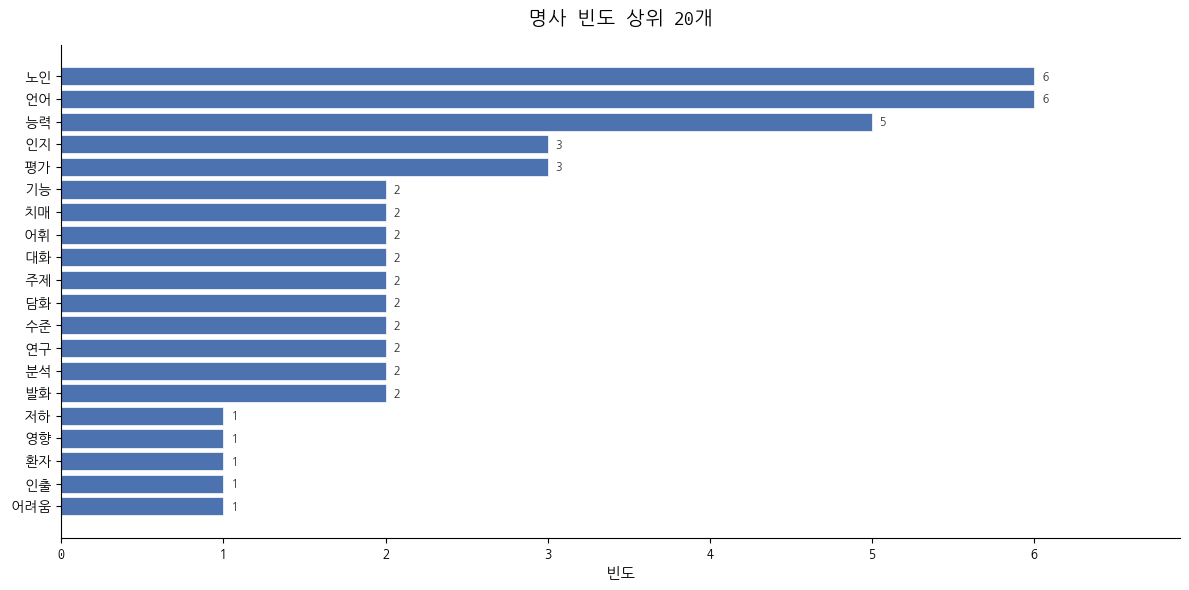

In [ ]:
# ════════════════════════════════════════════════════════════
#  시각화 함수 1: 수평 막대 그래프
# ════════════════════════════════════════════════════════════

def plot_frequency_bar(df_freq: pd.DataFrame,
                       title: str = '형태소 빈도',
                       color: str = '#4C72B0',
                       top_n: int = 20,
                       figsize: tuple = (12, 6)) -> None:
    """
    빈도 DataFrame을 수평 막대 그래프로 시각화합니다.

    매개변수
    --------
    df_freq  : frequency_analysis()의 반환 DataFrame
    title    : 그래프 제목
    color    : 막대 색상 (HEX 코드 또는 색상 이름)
    top_n    : 상위 몇 개 단어를 표시할지
    figsize  : 그림 크기 (가로, 세로) 인치 단위
    """
    df = df_freq.head(top_n).copy()
    fig, ax = plt.subplots(figsize=figsize)

    # [::-1]: 빈도 낮은 것이 아래, 높은 것이 위에 오도록 뒤집기
    bars = ax.barh(df['형태소'][::-1], df['빈도'][::-1], color=color,
                   edgecolor='white', linewidth=0.5)

    # 각 막대 오른쪽에 빈도 숫자 표시
    for bar, val in zip(bars, df['빈도'][::-1]):
        ax.text(bar.get_width() + 0.05,
                bar.get_y() + bar.get_height() / 2,
                str(val), va='center', fontsize=9, color='#333333')

    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('빈도', fontsize=11)
    ax.set_xlim(0, df['빈도'].max() * 1.15)  # 숫자 레이블 공간 확보

    # 불필요한 테두리(spine) 제거 → 깔끔한 디자인
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()


# ── 실행 예시 ─────────────────────────────────────────────────
# 더 풍부한 예시를 위해 긴 텍스트를 준비합니다.
long_text = """
노인의 인지 기능 저하는 언어 능력에도 영향을 미친다. 특히 치매 환자는 어휘 인출에 어려움을
겪고 대화 주제를 유지하는 능력이 저하된다. 경도 인지장애 노인은 담화 수준의 언어 능력이
감소하지만 일상 대화는 가능하다. 이야기 다시 말하기 과제에서 정상 노인과 치매 노인의
수행 능력 차이가 두드러진다. 명제 밀도와 어휘 다양도가 노인 언어 연구에서 중요한 지표로
활용된다. 담화 분석은 언어 능력 평가에서 문장 수준을 넘어서는 정보를 제공한다.
텍스트 마이닝 기법을 통해 대량의 발화 자료를 분석할 수 있다. 토픽 모델링은 발화 주제를
자동으로 추출하는 데 유용하다. 노인 언어 연구에서 형태소 분석은 매우 중요한 전처리 단계이다.
인지 기능 평가와 언어 평가를 함께 실시하면 더 정확한 진단이 가능하다.
"""

df_freq = frequency_analysis(long_text, preset='nouns', min_length=2, top_n=25)
plot_frequency_bar(df_freq, title='명사 빈도 상위 20개', top_n=20)

🎨 워드클라우드 생성 중...


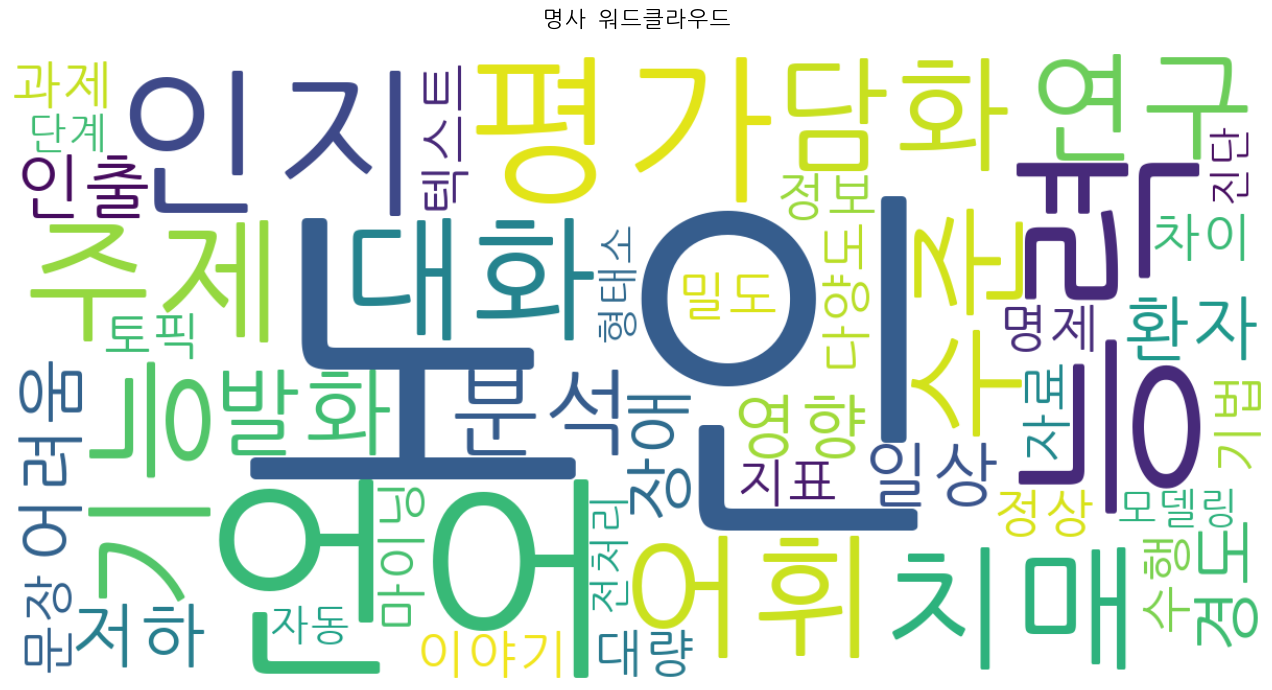

In [ ]:
# ════════════════════════════════════════════════════════════
#  시각화 함수 2: 워드클라우드
# ════════════════════════════════════════════════════════════
#
# WordCloud는 단어의 빈도에 비례하여 글자 크기를 조정합니다.
# generate_from_frequencies()에 {단어: 빈도} 딕셔너리를 전달합니다.

from wordcloud import WordCloud

def plot_wordcloud(text_or_freq,
                  preset: str = 'nouns',
                  min_length: int = 2,
                  custom_stopwords: list = None,
                  max_words: int = 100,
                  bg_color: str = 'white',
                  colormap: str = 'Blues',
                  figsize: tuple = (14, 7),
                  title: str = '워드클라우드') -> None:
    """
    텍스트 문자열 또는 빈도 DataFrame으로 워드클라우드를 생성합니다.

    colormap 옵션 예시:
      'Blues', 'Reds', 'viridis', 'plasma', 'Set2', 'tab10'
    """
    # 입력이 텍스트라면 빈도 분석을 먼저 수행
    if isinstance(text_or_freq, str):
        df_f = frequency_analysis(text_or_freq, preset=preset,
                                  min_length=min_length,
                                  custom_stopwords=custom_stopwords,
                                  top_n=max_words)
    else:
        df_f = text_or_freq

    # DataFrame → 딕셔너리 변환 (WordCloud 입력 형식)
    freq_dict = dict(zip(df_f['형태소'], df_f['빈도']))

    # WordCloud 객체 생성
    wc = WordCloud(
        font_path=font_path,          # 한글 폰트 경로 (1단계에서 설정)
        background_color=bg_color,
        colormap=colormap,
        max_words=max_words,
        width=1200, height=600,
        prefer_horizontal=0.85        # 85%는 가로 방향으로 배치
    ).generate_from_frequencies(freq_dict)

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(wc, interpolation='bilinear')  # bilinear: 부드러운 렌더링
    ax.axis('off')                           # 축 숨기기
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()


# ── 실행 예시 ─────────────────────────────────────────────────
print('🎨 워드클라우드 생성 중...')
plot_wordcloud(long_text, preset='nouns', min_length=2,
              title='명사 워드클라우드', colormap='viridis')

---
## 9단계. 언어적 지표 계산

### 📖 어휘 다양도(Lexical Diversity) 지표

어휘 다양도는 텍스트에서 얼마나 다양한 단어를 사용했는지를 측정합니다.  
노인 언어 연구에서 인지 기능 저하의 민감한 지표로 활용됩니다.

#### TTR (Type-Token Ratio)

$$\text{TTR} = \frac{\text{고유 단어 수 (Types)}}{\text{전체 단어 수 (Tokens)}}$$

- 범위: 0 ~ 1 (1에 가까울수록 어휘 다양)
- **단점**: 텍스트 길이에 따라 값이 달라짐 → 긴 텍스트일수록 TTR이 낮아지는 경향

#### MATTR (Moving Average TTR)

TTR의 단점을 보완한 지표입니다.  
일정 크기의 **이동 창(window)**을 사용해 텍스트 길이의 영향을 줄입니다.

```
window = 50이면:
  1~50번째 형태소 TTR → 계산
  2~51번째 형태소 TTR → 계산
  ...
  모든 창의 TTR 평균 = MATTR
```

> 📚 참고: Covington & McFall (2010). *Cutting the Gordian Knot: The Moving-Average Type-Token Ratio (MATTR).*

In [ ]:
# ════════════════════════════════════════════════════════════
#  언어적 지표 계산 함수 정의
# ════════════════════════════════════════════════════════════

import re

def split_sentences(text: str) -> list:
    """
    마침표(.), 물음표(?), 느낌표(!) 뒤의 공백을 기준으로
    텍스트를 문장 단위로 분리합니다.

    (?<=...)은 뒤돌아보기(lookbehind) 패턴입니다:
    '해당 문자 다음에 오는 공백'에서만 분리합니다.
    """
    sentences = re.split(r'(?<=[.?!])\s+', text.strip())
    return [s for s in sentences if s.strip()]


def compute_linguistic_metrics(text: str,
                               mattr_window: int = 50) -> pd.DataFrame:
    """
    텍스트의 주요 언어적 지표를 계산하여 DataFrame으로 반환합니다.

    계산 지표
    ---------
    - Token / Type 수
    - TTR (Type-Token Ratio)
    - MATTR (Moving Average TTR, 기본 window=50)
    - 명사 / 동사 / 형용사 수
    - 총 문장 수, 문장당 평균 형태소 수
    """
    pos_list = analyze_text(text, verbose=False)

    # 전체 형태소 (기호 제외)
    # 기호 태그 목록: SF, SP, SS, SE, SO, SW
    symbol_tags = {'SF', 'SP', 'SS', 'SE', 'SO', 'SW'}
    content_pos  = [(m, t) for m, t in pos_list if t not in symbol_tags]
    all_morphs   = [m for m, _ in content_pos]

    # 품사별 추출
    nouns = [m for m, t in pos_list if t in ['NNG', 'NNP']]
    verbs = [m for m, t in pos_list if t == 'VV']
    adjs  = [m for m, t in pos_list if t == 'VA']

    n_tokens = len(all_morphs)
    n_types  = len(set(all_morphs))

    # TTR 계산
    ttr = round(n_types / n_tokens, 4) if n_tokens > 0 else 0

    # MATTR 계산 (window 크기만큼 이동하며 TTR을 평균)
    if n_tokens >= mattr_window:
        ttrs = [
            len(set(all_morphs[i : i + mattr_window])) / mattr_window
            for i in range(n_tokens - mattr_window + 1)
        ]
        mattr = round(sum(ttrs) / len(ttrs), 4)
    else:
        # 텍스트가 window보다 짧으면 일반 TTR로 대체
        mattr = ttr
        print(f'⚠️  텍스트가 {mattr_window}개 미만이어서 MATTR 대신 TTR을 사용합니다.')

    sentences  = split_sentences(text)
    avg_morphs = round(n_tokens / len(sentences), 2) if sentences else 0

    metrics = {
        '총 형태소 수 (Token)':    n_tokens,
        '고유 형태소 수 (Type)':   n_types,
        'TTR (어휘 다양도)':        ttr,
        f'MATTR (window={mattr_window})': mattr,
        '명사 수 (NNG+NNP)':       len(nouns),
        '동사 수 (VV)':            len(verbs),
        '형용사 수 (VA)':          len(adjs),
        '총 문장 수':              len(sentences),
        '문장당 평균 형태소':       avg_morphs,
    }

    df = pd.DataFrame(list(metrics.items()), columns=['지표', '값'])
    return df


# ── 실행 예시 ─────────────────────────────────────────────────
df_metrics = compute_linguistic_metrics(long_text)

print('📊 언어적 지표 분석 결과')
print('   (TTR/MATTR: 값이 높을수록 어휘 다양도 높음)\n')
display(df_metrics)

📊 언어적 지표 분석 결과
   (TTR/MATTR: 값이 높을수록 어휘 다양도 높음)



,지표,값
0,총 형태소 수 (Token),162.0000
1,고유 형태소 수 (Type),95.0000
2,TTR (어휘 다양도),0.5864
3,MATTR (window=50),0.8274
4,명사 수 (NNG+NNP),74.0000
5,동사 수 (VV),14.0000
6,형용사 수 (VA),7.0000
7,총 문장 수,10.0000
8,문장당 평균 형태소,16.2000


---
## 10단계. 결과 내보내기 (CSV / Excel)

### 📖 파일 저장 형식 선택 기준

| 형식 | 장점 | 권장 상황 |
|------|------|----------|
| **CSV** | 가볍고 어떤 프로그램에서도 열림 | 추가 분석(SPSS, R) 입력용 |
| **Excel (.xlsx)** | 여러 시트, 서식 지원 | 보고서 제출, 공유용 |

### 💡 한글 깨짐 방지: `utf-8-sig` 인코딩

CSV 파일을 Windows Excel에서 열 때 한글이 깨지는 경우가 있습니다.  
`encoding='utf-8-sig'`를 사용하면 **BOM(Byte Order Mark)** 이 파일 앞에 추가되어  
Excel이 한글 인코딩을 자동으로 인식합니다.

In [ ]:
# ════════════════════════════════════════════════════════════
#  CSV / Excel 저장 및 자동 다운로드
# ════════════════════════════════════════════════════════════

from google.colab import files as colab_files

def save_and_download(df: pd.DataFrame,
                      filename: str = 'result',
                      fmt: str = 'csv') -> None:
    """
    DataFrame을 파일로 저장하고 자동으로 다운로드합니다.

    매개변수
    --------
    df       : 저장할 DataFrame
    filename : 파일 이름 (확장자 제외)
    fmt      : 'csv' 또는 'excel'
    """
    if fmt == 'excel':
        fname = f'{filename}.xlsx'
        # index=True: 순위 인덱스도 함께 저장
        df.to_excel(fname, index=True)
        print(f'💾 Excel 파일 저장: {fname}')
    else:
        fname = f'{filename}.csv'
        # utf-8-sig: Windows Excel에서 한글 깨짐 방지를 위한 BOM 포함 UTF-8
        df.to_csv(fname, index=True, encoding='utf-8-sig')
        print(f'💾 CSV 파일 저장: {fname}')

    # Colab의 파일 다운로드 기능 호출
    colab_files.download(fname)
    print(f'   → 브라우저 다운로드 폴더에서 확인하세요.')


# ── 실행 예시 ─────────────────────────────────────────────────

# 1. 빈도 분석 결과 → CSV 저장
df_freq_export = frequency_analysis(long_text, preset='nouns',
                                    min_length=2, top_n=50)
save_and_download(df_freq_export, filename='명사_빈도분석', fmt='csv')

# 2. 일괄 처리 결과 → Excel 저장
save_and_download(df_batch, filename='참여자별_형태소분석', fmt='excel')

# 3. 언어적 지표 → CSV 저장
save_and_download(df_metrics, filename='언어적지표', fmt='csv')

💾 CSV 파일 저장: 명사_빈도분석.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   → 브라우저 다운로드 폴더에서 확인하세요.
💾 Excel 파일 저장: 참여자별_형태소분석.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   → 브라우저 다운로드 폴더에서 확인하세요.
💾 CSV 파일 저장: 언어적지표.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   → 브라우저 다운로드 폴더에서 확인하세요.


---
## 11단계. 그룹 간 비교 분석

### 📖 그룹 간 비교의 중요성

임상 언어학 연구에서는 단순 빈도보다 **그룹 간 사용 패턴의 차이**가 더 중요합니다.  
예를 들어:
- 경도인지장애(MCI) vs. 정상 노인(NC)
- 치매 중증도별 그룹 (CDR 0 / CDR 0.5 / CDR 1)
- 자극 제시 조건별 그룹 (청각 / 시각)

### 💡 비율(%) 비교의 이유

그룹별 텍스트 분량이 다를 경우 **절대 빈도**로 비교하면 왜곡이 생깁니다.  
**비율(%)**로 변환하면 텍스트 길이를 보정하여 공정한 비교가 가능합니다.

📊 그룹 간 명사 사용 패턴 비교
   (비율이 높을수록 해당 그룹에서 자주 사용된 단어)
--------------------------------------------------


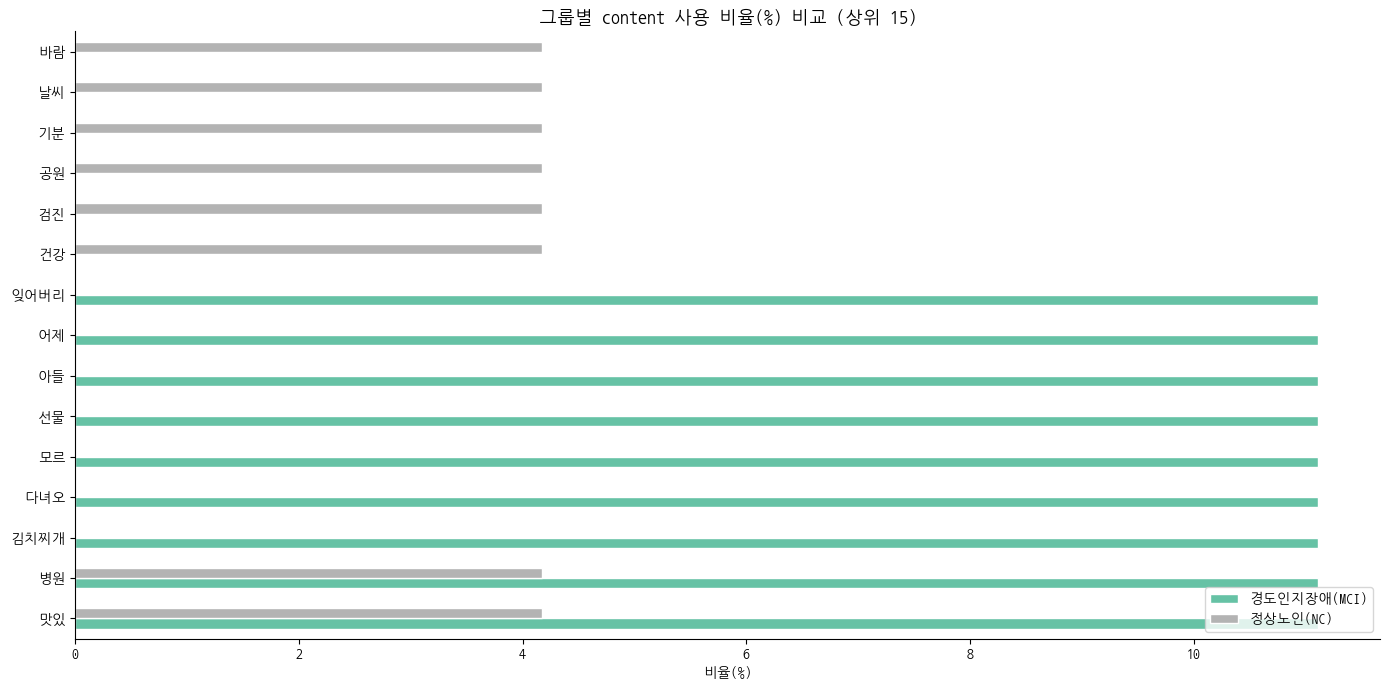


── 수치 비교표 ──


,경도인지장애(MCI),정상노인(NC)
맛있,11.11,4.17
병원,11.11,4.17
김치찌개,11.11,0.00
다녀오,11.11,0.00
모르,11.11,0.00
선물,11.11,0.00
아들,11.11,0.00
어제,11.11,0.00
잊어버리,11.11,0.00
건강,0.00,4.17


In [ ]:
# ════════════════════════════════════════════════════════════
#  그룹 간 형태소 사용 비교 함수
# ════════════════════════════════════════════════════════════

def compare_groups(texts_dict: dict,
                   preset: str = 'nouns',
                   min_length: int = 2,
                   top_n: int = 15,
                   figsize: tuple = (14, 7)) -> pd.DataFrame:
    """
    그룹별 형태소 사용 비율(%)을 비교하는 함수입니다.

    매개변수
    --------
    texts_dict : {'그룹명': '텍스트 또는 텍스트 리스트'}
    top_n      : 각 그룹에서 상위 몇 개 단어를 포함할지

    반환값
    ------
    pd.DataFrame : 단어를 행, 그룹을 열로 하는 비율(%) 비교표
    """
    group_freqs = {}

    for group_name, text in texts_dict.items():
        # 리스트인 경우 공백으로 합쳐서 하나의 텍스트로 처리
        if isinstance(text, list):
            text = ' '.join(text)

        df_f = frequency_analysis(text, preset=preset,
                                  min_length=min_length, top_n=100)
        # {단어: 비율} 딕셔너리로 저장
        group_freqs[group_name] = dict(zip(df_f['형태소'], df_f['비율(%)']))

    # 모든 그룹에서 상위 단어를 모아 비교 대상 목록 구성
    all_words = set()
    for gf in group_freqs.values():
        all_words.update(list(gf.keys())[:top_n])

    # 비교 DataFrame 생성 — 없는 단어는 0으로 채움
    df_cmp = pd.DataFrame(
        {
            g: [gf.get(w, 0) for w in sorted(all_words)]
            for g, gf in group_freqs.items()
        },
        index=sorted(all_words)
    )

    # 합계가 높은 상위 top_n 단어만 시각화
    df_top = df_cmp.loc[df_cmp.sum(axis=1).nlargest(top_n).index]

    # 그래프 출력
    ax = df_top.plot(kind='barh', figsize=figsize,
                     colormap='Set2', edgecolor='white')
    ax.set_title(f'그룹별 {preset} 사용 비율(%) 비교 (상위 {top_n})',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('비율(%)')
    ax.legend(loc='lower right', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

    return df_top


# ════════════════════════════════════════════════════════════
#  실습: 경도인지장애 vs 정상노인 그룹 비교
# ════════════════════════════════════════════════════════════

# 각 그룹의 발화 예시 (실제 연구에서는 더 많은 데이터 사용)
mci_texts = [
    '병원에 다녀왔어요. 약을 받았는데 뭔지 잘 모르겠어요. 많이 먹어야 해요.',
    '밥을 먹었어요. 맛있었는데... 뭘 먹었더라. 아 김치찌개요.',
    '아들이 왔다 갔어요. 어제였나. 선물을 줬는데 뭔지 잊어버렸어요.',
]
normal_texts = [
    '오늘 아침에 손자와 함께 공원을 산책했어요. 날씨가 맑고 바람이 시원해서 기분이 좋았어요.',
    '어제 병원에서 정기 검진을 받았어요. 의사 선생님이 건강 상태가 양호하다고 하셨어요.',
    '친구들과 경로당에서 점심을 먹었어요. 된장찌개와 잡채가 나왔는데 모두 맛있게 먹었어요.',
]

print('📊 그룹 간 명사 사용 패턴 비교')
print('   (비율이 높을수록 해당 그룹에서 자주 사용된 단어)')
print('-' * 50)

df_compare = compare_groups(
    {'경도인지장애(MCI)': mci_texts, '정상노인(NC)': normal_texts},
    preset='content', min_length=2, top_n=15
)

print('\n── 수치 비교표 ──')
display(df_compare.round(2))

---
## 12단계. 전체 분석 파이프라인 (원클릭 실행)

### 📖 파이프라인(Pipeline)이란?

> 여러 처리 단계를 **순서대로 자동 실행**하는 구조를 파이프라인이라고 합니다.

지금까지 배운 모든 단계를 하나의 함수 `full_pipeline()`으로 통합하면:  
- 텍스트 데이터만 준비하면 **분석 → 시각화 → 저장**이 자동으로 실행됩니다.
- 매번 같은 코드를 반복 실행할 필요가 없습니다.
- 여러 연구 프로젝트에서 **재사용 가능한 분석 도구**가 됩니다.

### 🔄 파이프라인 흐름도

```
텍스트 입력
    ↓
[1] 형태소 분석 (Bareun API 호출)
    ↓
[2] 품사 필터링 + 불용어 제거
    ↓
[3] 빈도 분석 + 언어적 지표 계산
    ↓
[4] 막대 그래프 + 워드클라우드
    ↓
[5] CSV / Excel 파일 저장
```

╔═════════════════════════════════════════════════════╗
║      바른 형태소 분석 파이프라인 시작           ║
╚═════════════════════════════════════════════════════╝

   텍스트 수: 3개 | 프리셋: nouns | 최소 길이: 2글자

[1/4] 📝 형태소 분석 중...

✅ 분석 완료: 3개 텍스트 | 추출 형태소 총 10개

[2/4] 📊 빈도 분석 중...

   ── 빈도 상위 15개 ──


,형태소,빈도,비율(%)
순위,,,
1,오늘,1,10.0
2,아침,1,10.0
3,반찬,1,10.0
4,김치,1,10.0
5,된장국,1,10.0
6,병원,1,10.0
7,의사,1,10.0
8,선생,1,10.0
9,손자,1,10.0



[3/4] 📐 언어적 지표 계산 중...


,지표,값
0,총 형태소 수 (Token),56.0000
1,고유 형태소 수 (Type),39.0000
2,TTR (어휘 다양도),0.6964
3,MATTR (window=50),0.6971
4,명사 수 (NNG+NNP),13.0000
5,동사 수 (VV),7.0000
6,형용사 수 (VA),3.0000
7,총 문장 수,6.0000
8,문장당 평균 형태소,9.3300



[4/4] 🎨 시각화 생성 중...


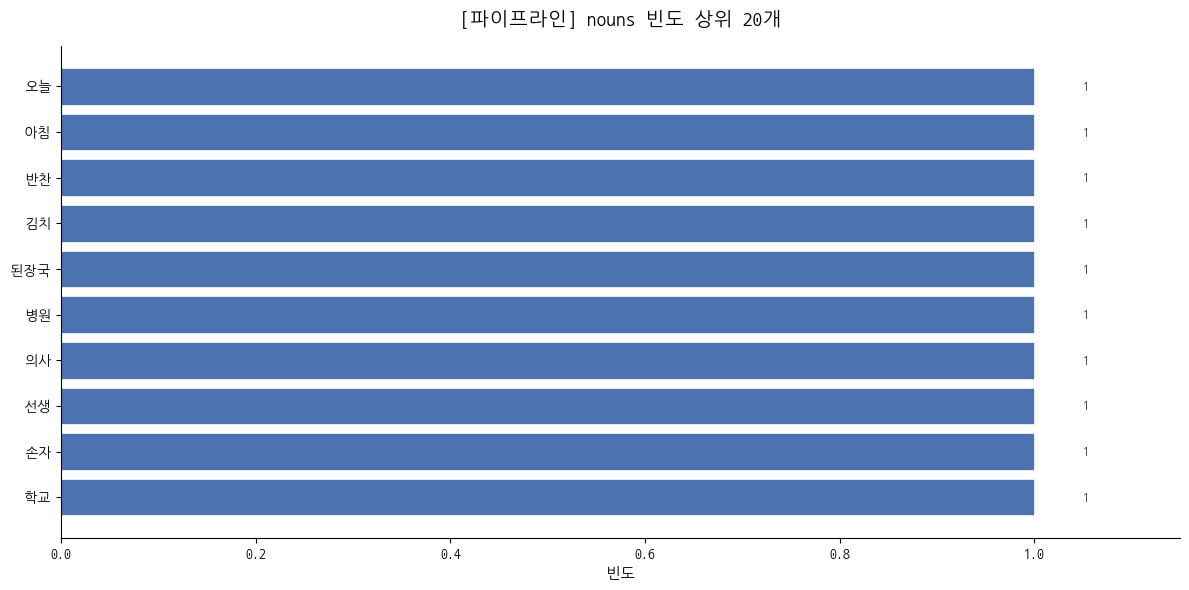

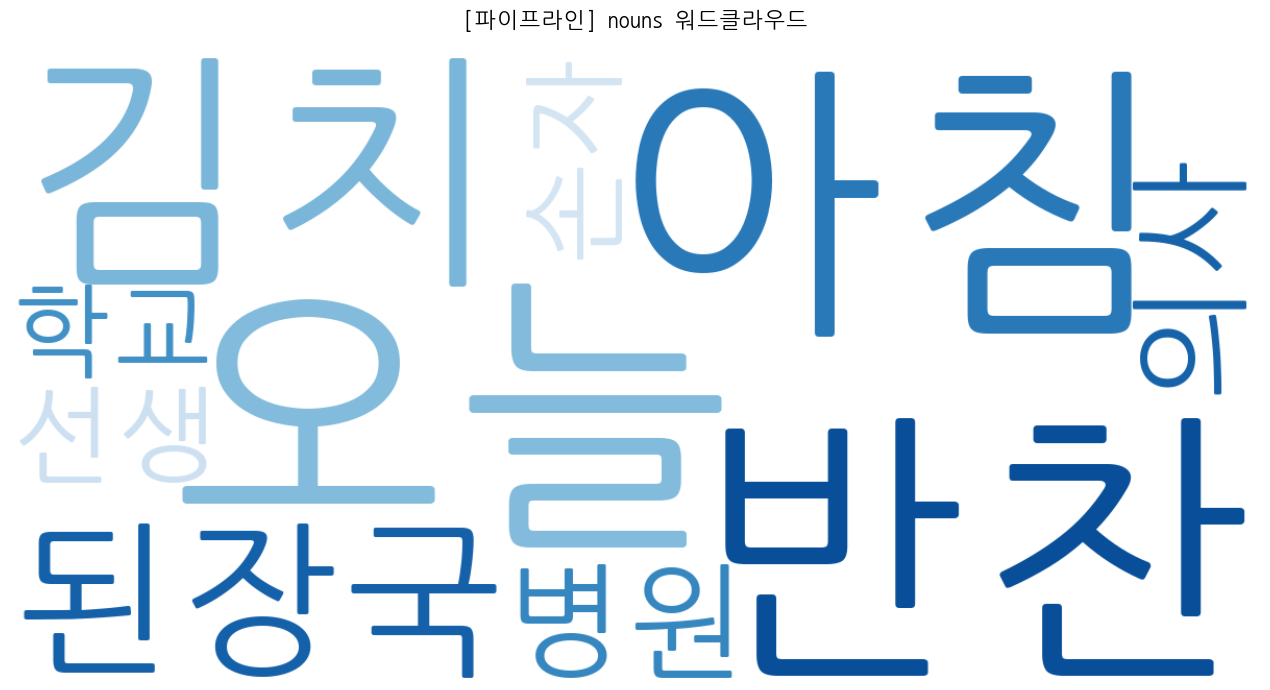


[💾] 결과 파일 저장 중...
💾 CSV 파일 저장: 결과_빈도분석.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   → 브라우저 다운로드 폴더에서 확인하세요.
💾 CSV 파일 저장: 결과_형태소전체.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   → 브라우저 다운로드 폴더에서 확인하세요.
💾 CSV 파일 저장: 결과_언어지표.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   → 브라우저 다운로드 폴더에서 확인하세요.

✅ 파이프라인 완료!


In [ ]:
# ════════════════════════════════════════════════════════════
#  전체 분석 파이프라인
# ════════════════════════════════════════════════════════════

def full_pipeline(texts: list,
                  labels: list = None,
                  preset: str = 'nouns',
                  min_length: int = 2,
                  custom_stopwords: list = None,
                  export: bool = True,
                  export_format: str = 'csv') -> dict:
    """
    입력 텍스트에 대해 형태소 분석부터 결과 저장까지 전 과정을 자동 실행합니다.

    매개변수
    --------
    texts            : 분석할 텍스트 리스트
    labels           : 텍스트 레이블 (참여자 ID 등)
    preset           : 품사 프리셋
    min_length       : 최소 형태소 길이
    custom_stopwords : 추가 불용어
    export           : True이면 결과 파일 자동 저장 및 다운로드
    export_format    : 'csv' 또는 'excel'

    반환값
    ------
    dict: {'batch': DataFrame, 'freq': DataFrame, 'metrics': DataFrame}
    """
    # 분석을 위해 모든 텍스트를 하나로 합칩니다.
    combined_text = ' '.join(texts)

    print('╔' + '═' * 53 + '╗')
    print('║      바른 형태소 분석 파이프라인 시작           ║')
    print('╚' + '═' * 53 + '╝')
    print(f'\n   텍스트 수: {len(texts)}개 | 프리셋: {preset} | '
          f'최소 길이: {min_length}글자')

    # ── Step 1. 일괄 형태소 분석 ──────────────────────────────
    print('\n[1/4] 📝 형태소 분석 중...')
    df_batch_result = batch_analyze(
        texts, labels=labels, preset=preset,
        min_length=min_length, custom_stopwords=custom_stopwords
    )

    # ── Step 2. 전체 빈도 분석 ────────────────────────────────
    print('\n[2/4] 📊 빈도 분석 중...')
    df_freq_result = frequency_analysis(
        combined_text, preset=preset, min_length=min_length,
        custom_stopwords=custom_stopwords, top_n=30
    )
    print('\n   ── 빈도 상위 15개 ──')
    display(df_freq_result.head(15))

    # ── Step 3. 언어적 지표 계산 ──────────────────────────────
    print('\n[3/4] 📐 언어적 지표 계산 중...')
    df_metrics_result = compute_linguistic_metrics(combined_text)
    display(df_metrics_result)

    # ── Step 4. 시각화 ────────────────────────────────────────
    print('\n[4/4] 🎨 시각화 생성 중...')
    plot_frequency_bar(df_freq_result,
                       title=f'[파이프라인] {preset} 빈도 상위 20개')
    if font_path:
        plot_wordcloud(df_freq_result,
                       title=f'[파이프라인] {preset} 워드클라우드')

    # ── Step 5. 결과 저장 ─────────────────────────────────────
    if export:
        print('\n[💾] 결과 파일 저장 중...')
        save_and_download(df_freq_result,   '결과_빈도분석',   export_format)
        save_and_download(df_batch_result,  '결과_형태소전체', export_format)
        save_and_download(df_metrics_result,'결과_언어지표',   export_format)

    print('\n✅ 파이프라인 완료!')
    return {
        'batch':   df_batch_result,
        'freq':    df_freq_result,
        'metrics': df_metrics_result
    }


# ════════════════════════════════════════════════════════════
#  ▶ 파이프라인 실행 — 아래 설정만 바꾸어 사용하세요!
# ════════════════════════════════════════════════════════════

results = full_pipeline(
    texts    = utterances,          # 분석할 텍스트 리스트
    labels   = participant_ids,     # 참여자 ID 리스트
    preset   = 'nouns',             # 'nouns' / 'verbs' / 'content' / 'open_class'
    min_length = 2,                 # 1음절 단어 제외
    custom_stopwords = ['것', '수'], # 추가 제거 단어
    export   = True,                # 파일 저장 여부
    export_format = 'csv'           # 'csv' 또는 'excel'
)

---
## 📚 마무리: 핵심 함수 요약

| 함수 | 주요 매개변수 | 반환값 |
|------|-------------|-------|
| `analyze_text(text)` | `verbose=True/False` | `list of (형태소, 품사)` |
| `filter_by_pos(pos_list)` | `preset`, `min_length` | `list of (형태소, 품사)` |
| `remove_stopwords(morph_list)` | `custom_stopwords` | `list of (형태소, 품사)` |
| `frequency_analysis(text)` | `preset`, `top_n` | `pd.DataFrame` |
| `batch_analyze(texts)` | `labels`, `delay` | `pd.DataFrame` |
| `plot_frequency_bar(df)` | `top_n`, `color` | (시각화 출력) |
| `plot_wordcloud(text)` | `colormap`, `max_words` | (시각화 출력) |
| `compute_linguistic_metrics(text)` | `mattr_window` | `pd.DataFrame` |
| `compare_groups(texts_dict)` | `preset`, `top_n` | `pd.DataFrame` |
| `full_pipeline(texts)` | (모든 매개변수 포함) | `dict of DataFrames` |

---

### 🚀 다음 단계 제안

1. **더 많은 데이터 적용**: 실제 연구 코퍼스에 `full_pipeline()`을 적용해 보세요.
2. **그룹 간 통계 검증**: 추출한 지표(TTR, MATTR 등)에 t-검정, Mann-Whitney 검정 적용
3. **토픽 모델링 연계**: 추출한 명사 리스트를 LDA 또는 BERTopic 입력으로 활용
4. **IU 분석 연계**: 형태소 분석 결과를 발화 단위(IU) 분석의 전처리로 활용

---

> 💬 **질문이 있으신가요?**  
> 각 함수의 `"""` 안의 독스트링(docstring)을 읽어보시거나, 셀을 직접 수정하여 실험해 보세요.  
> 오류가 발생하면 **런타임 → 모두 다시 시작** 후 처음부터 다시 실행해 보세요.